# 실습 내용

- 데이터 : titanic_train.csv
- kNN 알고리즘 사용

# 1.환경 준비

- 기본 **라이브러리**와 대상 **데이터**를 가져와 이후 과정을 준비합니다.

In [167]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'


In [168]:
# 데이터 읽어오기
path = './../00_data/titanic_train.csv'
df = pd.read_csv(path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2.데이터 이해

- 분석할 데이터를 **충분히 이해**할 수 있도록 다양한 **탐색** 과정을 수행합니다.

In [169]:
# 상/하위 몇 개 행 확인
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [170]:
# 하위 몇 개 행 확인
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [171]:
# 변수 확인
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [172]:
# 기술통계 확인
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [173]:
# 상관관계 확인
df.value_counts()
# df['Sex'].value_counts()
df.corr(numeric_only=True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


# 3.데이터 전처리

- **전처리** 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비합니다.

**1) 변수 추가**
- 분석에 의미가 있다고 판단되는 변수를 추가합니다.

In [174]:
# Title 변수 추가
df['Title'] = 'Others'

# 중요 호칭외에는 Others로 변경
def extract_title(name):
  if 'Mr.' in name:
    return 'Mr'
  elif 'Mrs.' in name:
    return 'Mrs'
  elif 'Miss.' in name:
    return 'Miss'
  elif 'Master' in name:
    return 'Master'
  else:
    return 'Others'

df['Title'] = df['Name'].apply(extract_title)
# 확인
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


**2) 변수 제거**

- 분석에 의미가 없다고 판단되는 변수는 제거합니다.

In [175]:
# 제거 대상: PassengerId, Name, Ticket, Cabin
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)
# 확인
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


**3) 결측치 처리**

- 결측치가 있으면 제거하거나 적절한 값으로 채웁니다.

In [176]:
# # Age 결측치를 Title 별 중앙값으로 채우기
print(df['Age'].isna().sum())

mean_age_by_title = df.groupby('Title')['Age'].median()
print(mean_age_by_title)

177
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Others    44.5
Name: Age, dtype: float64


In [177]:
df['Age']=df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Title       0
dtype: int64

In [178]:
# df['Age'] = df['Age'].fillna(df['Title'].map(mean_age_by_title))
# df.isna().sum()

In [179]:
# for title, mean_age in mean_age_by_title.items():
#     df.loc[(df['Title'] == title) & (df['Age'].isna()), 'Age'] = mean_age

In [180]:
# def fill_age(group):
#     group['Age'] = group['Age'].fillna(group['Age'].mean())
#     return group

# df = df.groupby('Title').apply(fill_age).reset_index(drop=True)

In [181]:

# df['Age'] = df['Age'].fillna(df['Title'].map(mean_age_by_title))

In [182]:
# Embarked 최빈값 'S'로 채우기

df['Embarked'].isna().sum()

np.int64(2)

In [183]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [184]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [185]:
df['Embarked'] = df['Embarked'].fillna('S')

In [186]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [187]:
df['Embarked'].isna().sum()

np.int64(0)

In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
 8   Title     891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


In [189]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [190]:
df['Sex'] = df['Sex'].replace({'male':0})
df['Sex'] = df['Sex'].replace({'female':1})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,Mr
1,1,1,1,38.0,1,0,71.2833,C,Mrs
2,1,3,1,26.0,0,0,7.9250,S,Miss
3,1,1,1,35.0,1,0,53.1000,S,Mrs
4,0,3,0,35.0,0,0,8.0500,S,Mr


In [191]:
df['Embarked'].value_counts()
df['Embarked'] = df['Embarked'].replace({'C':0})
df['Embarked'] = df['Embarked'].replace({'S':1})
df['Embarked'] = df['Embarked'].replace({'Q':2})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,1,Mr
1,1,1,1,38.0,1,0,71.2833,0,Mrs
2,1,3,1,26.0,0,0,7.9250,1,Miss
3,1,1,1,35.0,1,0,53.1000,1,Mrs
4,0,3,0,35.0,0,0,8.0500,1,Mr


In [192]:
df['Title'].value_counts()
df['Title'] = df['Title'].replace({'Mr':0})
df['Title'] = df['Title'].replace({'Miss':1})
df['Title'] = df['Title'].replace({'Mrs':2})
df['Title'] = df['Title'].replace({'Master':3})
df['Title'] = df['Title'].replace({'Others':4})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,1,0
1,1,1,1,38.0,1,0,71.2833,0,2
2,1,3,1,26.0,0,0,7.9250,1,1
3,1,1,1,35.0,1,0,53.1000,1,2
4,0,3,0,35.0,0,0,8.0500,1,0


In [193]:
df['Title'].value_counts()

Title
0    517
1    182
2    125
3     40
4     27
Name: count, dtype: int64

**3) x, y 분리**

- 우선 target 변수를 명확히 지정합니다.
- target을 제외한 나머지 변수들 데이터는 x로 선언합니다.
- target 변수 데이터는 y로 선언합니다.
- 이 결과로 만들어진 x는 데이터프레임, y는 시리즈가 됩니다.
- 이후 모든 작업은 x, y를 대상으로 진행합니다.

In [194]:
# target 확인
target = 'Survived'


# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]


**4) 가변수화**

- 범주형 변수를 가변수화 합니다.

- drop_first=True 로 설정하면 새로 생성되는 열 중 하나(맨 앞)를 제거할 수 있습니다.
- 다중공선성 해결을 위한 옵션
- 성능이 좋아지고 안 좋아지고는 **시도** 해보지 않고는 알 수 없다.

In [195]:
# # 가변수화 대상: Pclass, Sex, Embarked
# # -> 숫자로 바꿔라

# df = pd.get_dummies(df, columns=['Pclass', 'Sex', 'Embarked'])

# df.head()
# # 가변수화

# #  확인

In [197]:
# 가변수화 대상: Pclass, Sex, Embarked
# -> 숫자로 바꿔라

X = pd.get_dummies(X, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)

X.head()
# 가변수화

#  확인


,Age,SibSp,Parch,Fare,Title,Pclass_2,Pclass_3,Sex_1,Embarked_1,Embarked_2
0,22.0,1,0,7.2500,0,False,True,False,True,False
1,38.0,1,0,71.2833,2,False,False,True,False,False
2,26.0,0,0,7.9250,1,False,True,True,True,False
3,35.0,1,0,53.1000,2,False,False,True,True,False
4,35.0,0,0,8.0500,0,False,True,False,True,False


**6) 학습용, 평가용 데이터 분리**

- 학습용, 평가용 데이터를 적절한 비율로 분리합니다.
- 반복 실행 시 동일한 결과를 얻기 위해 random_state 옵션을 지정합니다.

In [ ]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=1)


# 4.모델링

- 본격적으로 모델을 **선언**하고 **학습**하고 **평가**하는 과정을 진행합니다.
- 우선 **회귀** 문제인지 **분류** 문제인지 명확히 구분합니다.

- 회귀 문제 인가요? 분류 문제인가요?
- 회귀인지 분류인지에 따라 사용할 알고리즘과 평가 방법이 달라집니다.
- 다음 알고리즘 사용
    - 알고리즘: KNeighborsClassifier

In [199]:
# 1단계: 불러오기
from sklearn.neighbors import KNeighborsClassifier

In [207]:
# 2단계: 선언하기

# 여기서 파라미터 값 설정
model = KNeighborsClassifier()

In [206]:
X_train

,Age,SibSp,Parch,Fare,Title,Pclass_2,Pclass_3,Sex_1,Embarked_1,Embarked_2
114,17.0,0,0,14.4583,1,False,True,True,False,False
874,28.0,1,0,24.0000,2,True,False,True,False,False
76,30.0,0,0,7.8958,0,False,True,False,True,False
876,20.0,0,0,9.8458,0,False,True,False,True,False
674,30.0,0,0,0.0000,0,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
715,19.0,0,0,7.6500,0,False,True,False,True,False
767,30.5,0,0,7.7500,1,False,True,True,False,True
72,21.0,0,0,73.5000,0,True,False,False,True,False
235,21.0,0,0,7.5500,1,False,True,True,True,False


In [208]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [209]:
# 4단계: 예측하기
y_pred = model.predict(X_test)

# 5.분류 성능 평가

- 다양한 성능 지표로 분류 모델 성능을 평가합니다.

**1) Confusion Matrix**

In [210]:
# 모듈 불러오기
from sklearn.metrics import confusion_matrix

# 성능 평가
confusion_matrix(y_test, y_pred)

array([[125,  28],
       [ 52,  63]])

<Axes: >

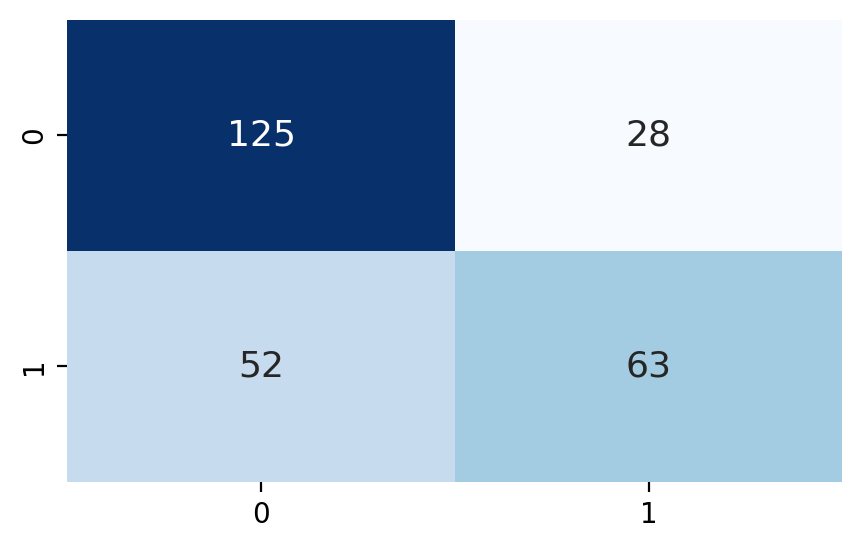

In [215]:
# 혼동행렬 시각화
#  분류 모델이 예측을 얼마나 잘했는지 한눈에 보여주는 표
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            cbar=False,
            cmap='Blues',
            fmt='d',
            annot_kws={'size':13})




**2) Accuracy**

In [216]:
# 모듈 불러오기
from sklearn.metrics import accuracy_score

# 성능 평가
print(accuracy_score(y_test, y_pred))

0.7014925373134329


**3) Precision**

In [217]:
# 모듈 불러오기
from sklearn.metrics import precision_score

# 성능 평가
precision_score(y_test, y_pred)

0.6923076923076923

**4) Recall**

In [218]:
# 모듈 불러오기
from sklearn.metrics import recall_score

# 성능 평가
print(recall_score(y_test, y_pred))


0.5478260869565217


**5) F1-Score**

In [219]:
# 모듈 불러오기
from sklearn.metrics import f1_score

# 성능 평가
print(f1_score(y_test, y_pred))

0.6116504854368932


**6) Classification Report**

In [221]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.82      0.76       153
           1       0.69      0.55      0.61       115

    accuracy                           0.70       268
   macro avg       0.70      0.68      0.68       268
weighted avg       0.70      0.70      0.69       268

